# Model 2_1
| Model type | Try | Comments |
|------------|-----|----------|
| 2 | 1 | Primera prueba con los datos de varias estaciones meteorologicas y con los IDs correctos|


In [8]:
version = "2_1"

In [9]:
import matplotlib.pyplot as plt

def show_history(history, model_name: str):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))  # 2 filas, 1 columna

    # Pérdida (loss)
    ax1.plot(history.history['loss'],     label='Training Loss',  color='green')
    ax1.plot(history.history['val_loss'], label='Validation Loss', color='blue')
    ax1.set_title('Loss evolution')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Precisión (accuracy)
    ax2.plot(history.history['accuracy'],     label='Training Accuracy',  color='green')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
    ax2.set_title('Accuracy evolution')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    # Título global
    fig.suptitle(model_name, fontsize=16)

    # Ajustar márgenes
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [10]:
import pickle
import pandas as pd
import numpy as np
import json

pd.set_option("display.max_rows", None)   # Muestra todas las filas
pd.set_option("display.max_columns", None)  # Muestra todas las columnas
pd.set_option("display.width", None)     # No corta la tabla en varias líneas
pd.set_option("display.max_colwidth", None)  # Muestra el contenido de celdas completo

In [11]:
with open("../../data/normalized/df_normalized_dayOfYear.pk1", "rb") as f:
    df_data = pickle.load(f)

In [12]:
df_data.dtypes

started_at                     datetime64[ns]
ride_id                                object
year                                    int64
event                                    bool
rideable_type_classic_bike               bool
rideable_type_docked_bike                bool
rideable_type_electric_bike              bool
member_casual_bool                       bool
day_type_Holiday                         bool
day_type_Normal                          bool
day_type_Weekend                         bool
temp_std                              float64
wind_std                              float64
rel_humidity_std                      float64
precipitation_std                     float64
snow_depth_std                        float64
start_station_idx                       int64
end_station_idx                         int64
hour_sin                              float64
hour_cos                              float64
month_sin                             float64
month_cos                         

In [15]:
df_model = df_data.drop(columns=[
    "ride_id",
    "started_at",
    "member_casual_bool",
    "rideable_type_classic_bike",
    "rideable_type_docked_bike",
    "rideable_type_electric_bike",    
    "duration_min"
])

In [16]:
df_model.head()

,year,event,day_type_Holiday,day_type_Normal,day_type_Weekend,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,start_station_idx,end_station_idx,hour_sin,hour_cos,month_sin,month_cos,doy_sin,doy_cos
0,2022,False,False,True,False,-2.348318,-0.573362,0.916001,-0.099704,-0.056148,1281,1896,0.937383,0.348299,0.0,1.0,0.068802,0.997630
1,2022,False,False,True,False,-2.299739,0.115036,1.211601,-0.099704,-0.056148,1819,1645,0.144284,-0.989536,0.0,1.0,0.068802,0.997630
2,2022,False,False,True,False,-2.299739,0.225945,1.378055,-0.099704,-0.056148,1250,1250,-0.316960,-0.948439,0.0,1.0,0.068802,0.997630
3,2022,False,False,True,False,-1.705422,-0.688095,0.996358,-0.099704,-0.056148,1896,1911,-0.793088,-0.609108,0.0,1.0,0.205104,0.978740
4,2022,False,False,False,True,-2.798966,-1.130964,0.884432,-0.099704,-0.056148,1893,1646,0.798460,-0.602047,0.0,1.0,0.271958,0.962309


In [21]:
# Variables de entrada
X = df_model.drop(columns=['start_station_idx', 'end_station_idx'])
X_start = df_model['start_station_idx']
y_end   = df_model['end_station_idx']

In [37]:
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model

X_train, X_test, X_start_train, X_start_test, y_end_train, y_end_test = train_test_split(
    X, 
    X_start, 
    y_end, 
    test_size=0.2, 
    random_state=42
)

# ---------- Normalizar índices de estaciones con un offset común
station_offset = int(min(X_start.min(), y_end.min()))
# desplazamos todos para que el mínimo sea 0
X_start_train_shift = (X_start_train - station_offset).astype(int)
X_start_test_shift  = (X_start_test  - station_offset).astype(int)
y_end_train_shift   = (y_end_train   - station_offset).astype(int)
y_end_test_shift    = (y_end_test    - station_offset).astype(int)

num_stations = int(max(X_start.max(), y_end.max()) - station_offset + 1)
num_features = X.shape[1]

print(f"Number of stations: {num_stations}")
print(f"Number of features: {num_features}")

# ---------- Preparar inputs en la forma que requieren los Embeddings: (n,1)
X_train_context = X_train.values.astype(np.float32)
X_test_context  = X_test.values.astype(np.float32)

start_train_input = X_start_train_shift.values.reshape(-1, 1)
start_test_input  = X_start_test_shift.values.reshape(-1, 1)


# Labels (etiquetas) para clasificación: estación destino (y_end)
y_train_labels = y_end_train_shift.values.astype(int)

# ---------- Opcional: split del train en train/val
X_t_ctx, X_val_ctx, start_t_in, start_val_in, y_t, y_val = train_test_split(
    X_train_context,
    start_train_input,
    y_train_labels,
    test_size=0.2,
    random_state=42
)

# ---------- Construcción del modelo (inputs y embeddings)
embedding_dim = int(np.ceil(np.sqrt(num_stations)))

context_input = layers.Input(shape=(num_features,), name="context")
start_input   = layers.Input(shape=(1,), name="start_station_input")

start_embed = layers.Embedding(input_dim=num_stations, output_dim=embedding_dim)(start_input)
start_embed = layers.Flatten()(start_embed)

x = layers.Concatenate()([context_input, start_embed])
x = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)

end_output = layers.Dense(num_stations, activation='softmax', name='end_station')(x)

model = Model(
    inputs=[context_input, start_input],
    outputs=end_output
)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Number of stations: 1912
Number of features: 16


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ start_station_input │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 44)     │     84,128 │ start_station_in… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context             │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 44)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 60)        │          0 │ context[0][0],    │
│ (Concatenate)       │                   │            │ flatten_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 128)       │      7,808 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 64)        │      8,256 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_station (Dense) │ (None, 1912)      │    124,280 │ dense_16[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 224,472 (876.84 KB)

 Trainable params: 224,472 (876.84 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
%%time

# ---------- Callbacks
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# ---------- Entrenamiento usando validation_data (más explícito y claro)
history = model.fit(
    {'context': X_t_ctx, 'start_station_input': start_t_in},
    y_t,
    validation_data=(
        {'context': X_val_ctx, 'start_station_input': start_val_in},
        y_val
    ),
    epochs=20,
    batch_size=128,
    callbacks=[callback]
)

Epoch 1/20
47554/47554 ━━━━━━━━━━━━━━━━━━━━ 180s 4ms/step - accuracy: 0.0290 - loss: 5.3837 - val_accuracy: 0.0438 - val_loss: 5.0574
Epoch 2/20
47554/47554 ━━━━━━━━━━━━━━━━━━━━ 179s 4ms/step - accuracy: 0.0449 - loss: 5.0108 - val_accuracy: 0.0495 - val_loss: 5.0142
Epoch 3/20
47554/47554 ━━━━━━━━━━━━━━━━━━━━ 173s 4ms/step - accuracy: 0.0466 - loss: 4.9782 - val_accuracy: 0.0517 - val_loss: 4.9312
Epoch 4/20
47554/47554 ━━━━━━━━━━━━━━━━━━━━ 173s 4ms/step - accuracy: 0.0469 - loss: 4.9680 - val_accuracy: 0.0474 - val_loss: 5.0151
Epoch 5/20
47554/47554 ━━━━━━━━━━━━━━━━━━━━ 171s 4ms/step - accuracy: 0.0471 - loss: 4.9629 - val_accuracy: 0.0458 - val_loss: 5.0738
Epoch 6/20
47554/47554 ━━━━━━━━━━━━━━━━━━━━ 171s 4ms/step - accuracy: 0.0472 - loss: 4.9603 - val_accuracy: 0.0452 - val_loss: 5.0449
CPU times: total: 1h 12min 40s
Wall time: 17min 26s


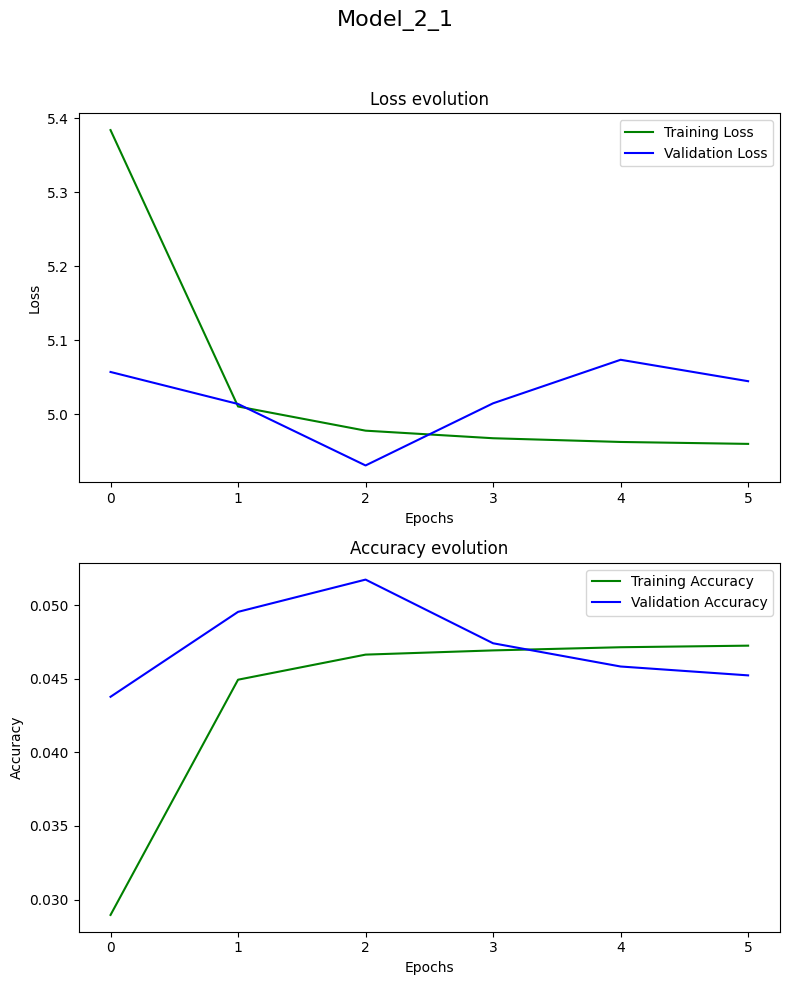

In [39]:
show_history(history, f"Model_{version}")

In [40]:
X_test_context  = X_test.values.astype(np.float32)
start_test_input  = (X_start_test - station_offset).values.reshape(-1, 1).astype(int)

test_metrics = model.evaluate(
    {'context': X_test_context, 'start_station_input': start_test_input},
    (y_end_test - station_offset).values.astype(int),
    verbose=2
)

59443/59443 - 70s - 1ms/step - accuracy: 0.0517 - loss: 4.9300


In [41]:
model.save(f"model_{version}.keras")

with open(f'history_{version}.json', 'w') as f:
    json.dump(history.history, f)

In [4]:
import json
import numpy as np

with open("history_2_1.json", "r", encoding="utf-8") as f:
    history = json.load(f)
    
# Mejor época según val_accuracy
best_epoch = np.argmax(history['val_accuracy'])
best_train_acc = history['accuracy'][best_epoch]
best_val_acc = history['val_accuracy'][best_epoch]
best_val_loss = history['val_loss'][best_epoch]

print("Mejor época:", best_epoch+1)
print("Mejor train_accuracy:", best_train_acc)
print("Mejor val_accuracy:", best_val_acc)
print("Mejor val_loss:", best_val_loss)

Mejor época: 3
Mejor train_accuracy: 0.04663572460412979
Mejor val_accuracy: 0.05172945186495781
Mejor val_loss: 4.931249618530273
